# Tracking a spiraling object using the extended Kalman filter

*This example is adapted from the [dynamax notebook "Tracking a spiraling object using the extended / unscented Kalman filter"](https://probml.github.io/dynamax/notebooks/nonlinear_gaussian_ssm/ekf_ukf_spiral.html). The original compares the EKF and UKF; we show the EKF, which the cuthbert backend provides.*

Consider an object moving in $\mathbb{R}^2$.
We assume that we observe a noisy version of its location at each time step.
We want to track the object and possibly forecast its future motion.
We now show how to do this using a simple nonlinear Gaussian SSM, combined with
extensions of the Kalman filter algorithm.

Let the hidden state represent
the position of the object,
$z_t = (u_t,\ v_t)$.
(We use $u$ and $v$ for the two coordinates,
to avoid confusion with the state and observation variables.)
We assume the following nonlinear dynamics:

\begin{align*}
z_t &= f(z_{t-1}) + q_t \\
f\left(\begin{pmatrix} u \\ v \end{pmatrix}\right)
 &= \begin{pmatrix} u + 0.4 \sin(v) \\ v + 0.4\cos(u) \end{pmatrix}
\end{align*}

where $q_t \in \mathbb{R}^2$ is the process noise, which we assume is Gaussian,
so  $q_t \sim \mathcal{N}(0,Q)$.


At each discrete time point we
observe the location corrupted by  Gaussian noise.
Thus the observation model becomes

\begin{align*}
y_t &= h(z_t) + r_t \\
h\left(\begin{pmatrix} u \\ v \end{pmatrix}\right) &= \begin{pmatrix} u \\ v \end{pmatrix}
\end{align*}

where $r_t \sim \mathcal{N}(0,R)$ is the observation noise.

We show how to perform approximate inference of the latent states in this nonlinear dynamical system model using an Extended Kalman Filter (EKF). This algorithm works by approximating the nonlinear model with a linear Gaussian model. For more detail, see Murphy (2023) or Särkkä and Svensson (2023).

## References
- Murphy, Kevin P. Probabilistic machine learning: Advanced topics. MIT press, 2023.
- Särkkä, Simo, and Lennart Svensson. Bayesian filtering and smoothing. Vol. 17. Cambridge university press, 2023.

## Setup

In [1]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro.distributions as dist
from matplotlib.patches import Ellipse, transforms
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, DynamicalModel
from dynestyx.inference.filters import EKFConfig, Filter
from dynestyx.inference.integrations.utils import covariance_from_cholesky
from dynestyx.models import GaussianObservation, GaussianStateEvolution

## Create the model

In [2]:
state_dim = 2
obs_dim = 2
f = lambda z: z + 0.4 * jnp.array([jnp.sin(z[1]), jnp.cos(z[0])])
h = lambda z: z

# In dynestyx the nonlinear dynamics go in a GaussianStateEvolution (mean
# function F) and the nonlinear emission in a GaussianObservation (mean h).
nlgssm = DynamicalModel(
    initial_condition=dist.MultivariateNormal(
        jnp.array([1.5, 0.0]), jnp.eye(state_dim)
    ),
    state_evolution=GaussianStateEvolution(
        F=lambda x, u, t_now, t_next: f(x), cov=jnp.eye(state_dim) * 0.001
    ),
    observation_model=GaussianObservation(
        h=lambda x, u, t: h(x), R=jnp.eye(obs_dim) * 0.05
    ),
)

## Sample some data from the model

In [3]:
key = jr.PRNGKey(0)
num_timesteps = 100
obs_times = jnp.arange(float(num_timesteps))


# Wrap the model in a NumPyro model so we can draw samples from it with Predictive.
def nlgssm_model(obs_times=None, obs_values=None, predict_times=None):
    return dsx.sample(
        "nlgssm",
        nlgssm,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )


with DiscreteTimeSimulator():
    sample = Predictive(nlgssm_model, num_samples=1)(key, predict_times=obs_times)
states = sample["nlgssm_states"][0, 0]
emissions = sample["nlgssm_observations"][0, 0]

In [4]:
def plot_inference(
    states, emissions, estimates=None, est_type="", ax=None, title="", show_states=True
):
    """Plot the states, emissions and (optionally) filtered estimates."""
    if ax is None:
        _, ax = plt.subplots()
    if show_states:
        ax.plot(*states.T, label="True States", lw=3)
    ax.plot(*emissions.T, ".", color="k", ms=6, label="Observations")
    if estimates is not None:
        ax.plot(
            *estimates.T, color="r", linewidth=1.5, ls="-", label=f"{est_type} Estimate"
        )
    ax.set_title(title)
    ax.legend(borderpad=0.5, handlelength=4, fancybox=False, edgecolor="k")
    ax.axis("equal")
    ax.set_xlabel(r"$u$")
    ax.set_ylabel(r"$v$")
    return ax


def plot_ellipse(cov, mean, ax, n_std=3.0, facecolor="none", edgecolor="k", **kwargs):
    """Plot an `n_std` covariance ellipse centred at `mean`."""
    pearson = cov[0, 1] / jnp.sqrt(cov[0, 0] * cov[1, 1])
    ellipse = Ellipse(
        (0, 0),
        width=2 * jnp.sqrt(1 + pearson),
        height=2 * jnp.sqrt(1 - pearson),
        facecolor=facecolor,
        edgecolor=edgecolor,
        **kwargs,
    )
    scale_x = jnp.sqrt(cov[0, 0]) * n_std
    scale_y = jnp.sqrt(cov[1, 1]) * n_std
    transform = (
        transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(*mean)
    )
    ellipse.set_transform(transform + ax.transData)
    return ax.add_patch(ellipse)


def plot_uncertainty_ellipses(means, covs, ax, n_std=3.0, label=None, **kwargs):
    """Add a covariance ellipse at each (mean, cov), labelling only the first."""
    for i, (cov, mean) in enumerate(zip(covs, means)):
        plot_ellipse(cov, mean, ax, n_std, label=label if i == 0 else None, **kwargs)

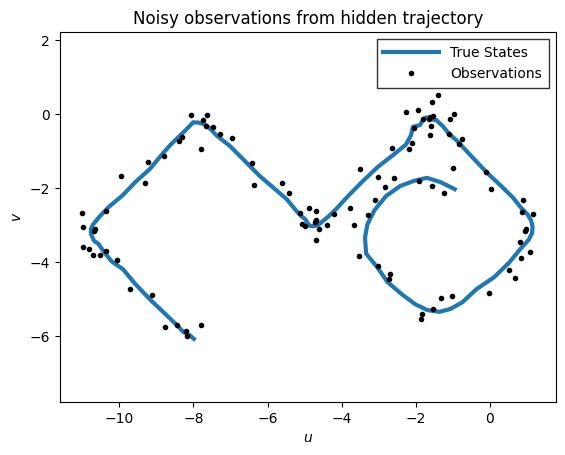

In [5]:
plot_inference(states, emissions, title="Noisy observations from hidden trajectory")
plt.show()

## Extended Kalman filter

The extended Kalman filter (EKF) is an approximate inference algorithm for systems with nonlinear dynamics and/or emissions and Gaussian noise. It works by using a first-order Taylor approximation to the dynamics and/or emissions functions, and then running a standard Kalman filter on the "linearized" model. The EKF tends to work well when the dynamics and emissions are well-approximated by their first-order Taylor function around the predictive means.

In [6]:
with Filter(
    filter_config=EKFConfig(
        filter_source="cuthbert",
        record_filtered_states_mean=True,
        record_filtered_states_cov=True,
    )
):
    ekf_post = dsx.condition(
        "nlgssm", nlgssm, obs_times=obs_times, obs_values=emissions
    )

ekf_means = ekf_post.states.mean
ekf_covs = covariance_from_cholesky(ekf_post.states.chol_cov)

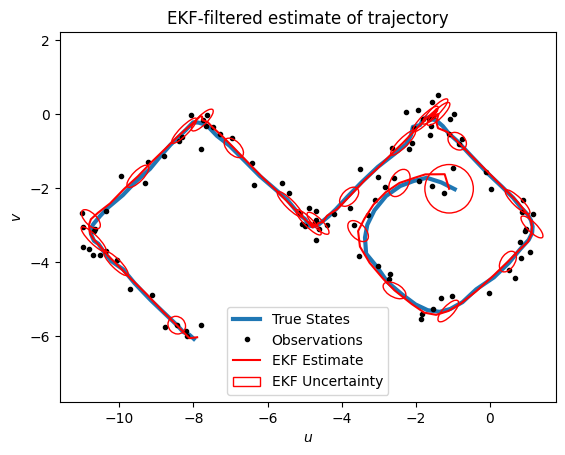

In [7]:
ax = plot_inference(
    states, emissions, ekf_means, "EKF", title="EKF-filtered estimate of trajectory"
)
# Add uncertainty ellipses to every fourth estimate
plot_uncertainty_ellipses(
    ekf_means[::4], ekf_covs[::4], ax, zorder=10, edgecolor="r", label="EKF Uncertainty"
)
plt.legend()
plt.show()